# Mensch ärgere Dich nicht — strategy research

Simulating many automated 4-player games to study:

1. average **game length**,
2. **win rates** per strategy — in particular **mean vs. nice**,
3. **first-player / seat advantage** (for every strategy),
4. supporting effects: aggression vs. success.

All heavy lifting lives in the `maedn` package; this notebook only makes high-level calls and plots.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # import maedn from the repo root

import pandas as pd
import matplotlib.pyplot as plt

from maedn import run_tournament, STRATEGIES
from maedn import analysis

ALL_STRATEGIES = sorted(STRATEGIES)
print('available strategies:', ALL_STRATEGIES)

available strategies: ['defensive', 'mean', 'nice', 'random', 'runahead']


## Configuration

In [2]:
SEATS = ['mean', 'nice', 'random', 'defensive']  # one strategy per seat
N_GAMES = 5000
SEED = 42

df = run_tournament(SEATS, n_games=N_GAMES, seed=SEED, rotate_seats=True)
df.head()

,game,turns,rolls,hit_turn_cap,winner_seat,winner_strategy,seat_0,made_0,suffered_0,seat_1,made_1,suffered_1,seat_2,made_2,suffered_2,seat_3,made_3,suffered_3
0,0,275,324,False,2,random,mean,8,7,nice,5,8,random,3,3,defensive,6,4
1,1,374,448,False,1,random,nice,7,8,random,10,9,defensive,10,7,mean,8,11
2,2,200,234,False,3,nice,random,3,3,defensive,1,1,mean,4,4,nice,1,1
3,3,343,413,False,2,nice,defensive,5,7,mean,9,6,nice,5,4,random,4,6
4,4,353,438,False,0,mean,mean,13,6,nice,2,13,random,9,9,defensive,13,9


## 1. Game length

count    5000.000000
mean      305.874800
std        70.045494
min       130.000000
25%       256.000000
50%       299.000000
75%       349.000000
max       626.000000
Name: turns, dtype: float64


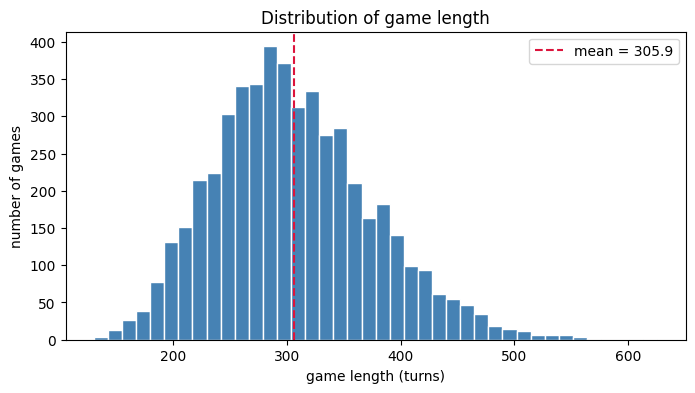

In [3]:
print(analysis.game_length_stats(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_length_hist(df, ax=ax)
plt.show()

## 2. Win rate per strategy

strategy
mean         0.4786
nice         0.2568
defensive    0.1440
random       0.1206
Name: is_winner, dtype: float64


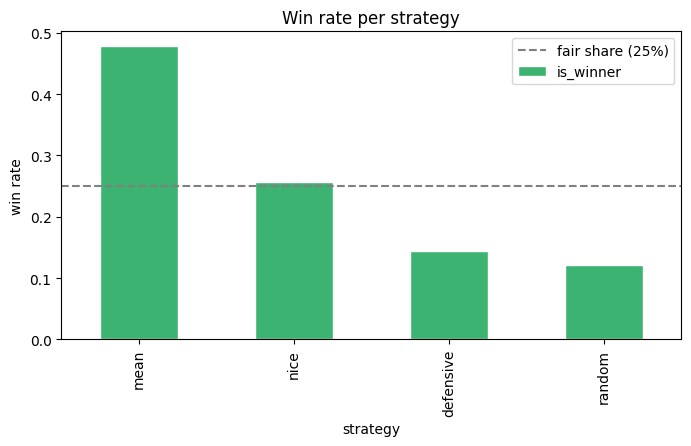

In [4]:
print(analysis.win_rates(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_win_rates(df, ax=ax)
plt.show()

## 3. Mean vs. Nice

The headline question: does aggression pay off?

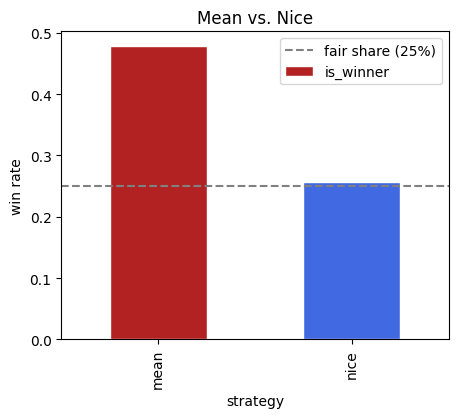

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
analysis.plot_mean_vs_nice(df, ax=ax)
plt.show()

## 4. Aggression vs. success

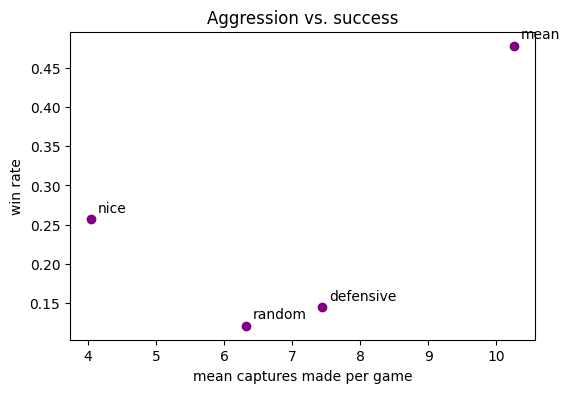

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
analysis.plot_captures_vs_winrate(df, ax=ax)
plt.show()

## 5. Does the first player have an advantage? (every strategy)

Seat 0 plays first. To isolate the **pure turn-order effect** we let all four seats use the *same*
strategy — then any win-rate difference between seats is positional, not a strategy artefact. We
repeat this controlled experiment for **every** strategy.

`seat_advantage` gives per-seat win rates with 95% confidence intervals; `seat_uniformity_test` runs a
chi-square test of whether the seat differences exceed chance (`significant=True` ⇒ turn order
matters for that strategy).

In [7]:
FPA_GAMES = 20000

# Run each controlled experiment once and reuse it for the table and the plots.
experiments = {
    s: analysis.first_player_experiment(strategy=s, n_games=FPA_GAMES, seed=0)
    for s in ALL_STRATEGIES
}

In [8]:
# Summary table: per-seat win rate + chi-square test, one row per strategy.
rows = {}
for s, exp in experiments.items():
    adv = analysis.seat_advantage(exp)['win_rate']
    test = analysis.seat_uniformity_test(exp)
    row = {f'seat_{seat}': adv[seat] for seat in adv.index}
    row['first_minus_last'] = adv.iloc[0] - adv.iloc[-1]
    row['chi2'] = test['chi2']
    row['significant'] = test['significant']
    rows[s] = row

summary = pd.DataFrame(rows).T
summary.round(4)

,seat_0,seat_1,seat_2,seat_3,first_minus_last,chi2,significant
defensive,0.25665,0.2497,0.24655,0.2471,0.00955,5.17,False
mean,0.25675,0.25095,0.24885,0.24345,0.0133,7.2552,False
nice,0.2609,0.2473,0.24855,0.24325,0.01765,13.9012,True
random,0.2499,0.24895,0.2527,0.24845,0.00145,0.8644,False
runahead,0.25905,0.2521,0.24425,0.2446,0.01445,11.8828,True


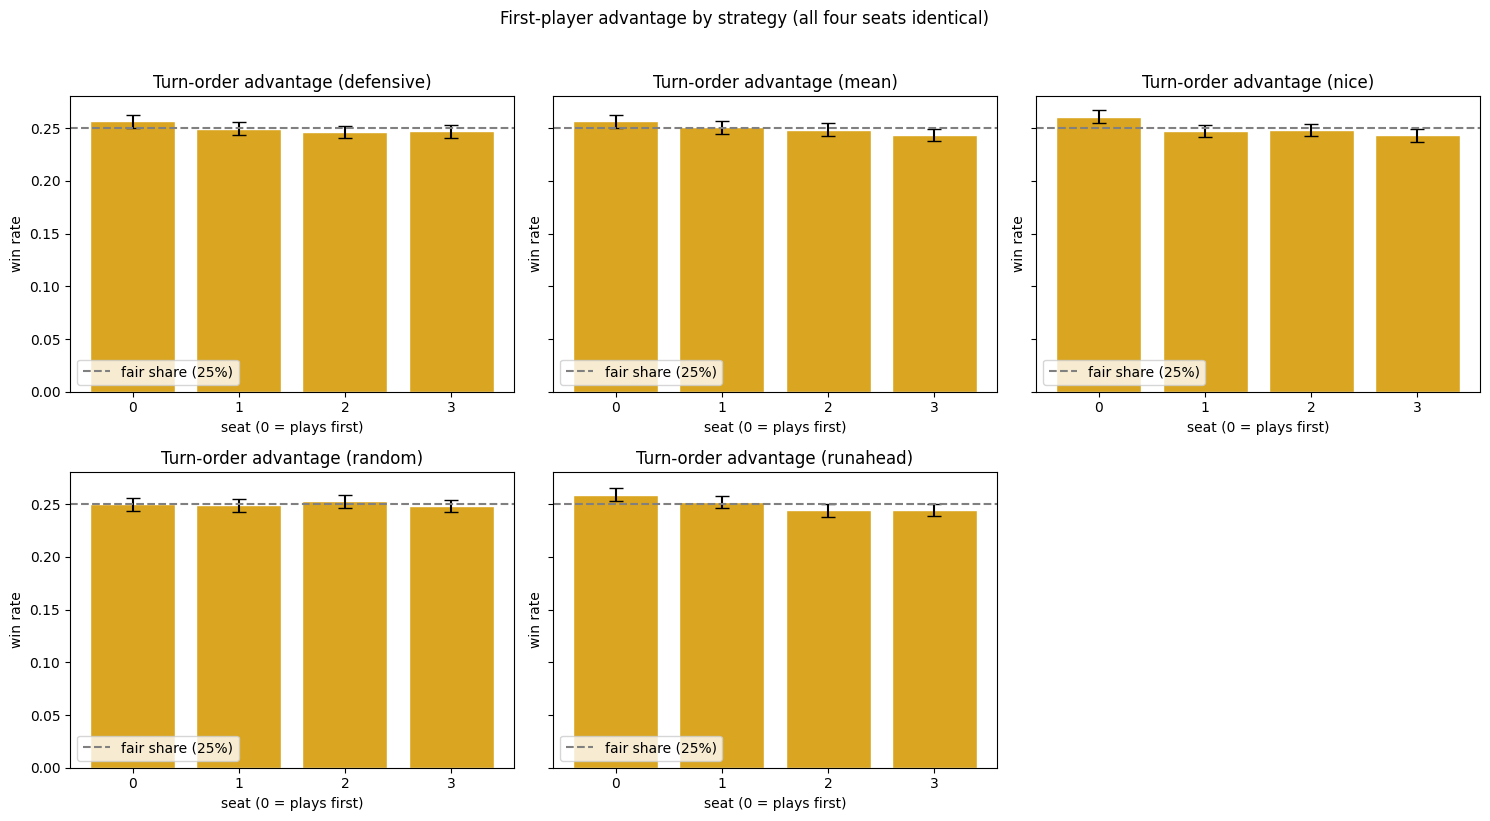

In [9]:
# One seat-advantage bar chart (with 95% CIs) per strategy.
ncols = 3
nrows = -(-len(ALL_STRATEGIES) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
for ax, s in zip(axes.flat, ALL_STRATEGIES):
    analysis.plot_seat_advantage(experiments[s], ax=ax)
    ax.set_title(f'Turn-order advantage ({s})')
for ax in axes.flat[len(ALL_STRATEGIES):]:
    ax.axis('off')  # hide unused panels
fig.suptitle('First-player advantage by strategy (all four seats identical)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Try your own match-ups

Each seat is independent, so any mix works — e.g. a 2-vs-2 mean/nice study, or one aggressor against three pacifists.

In [10]:
df_2v2 = run_tournament(['mean', 'mean', 'nice', 'nice'], n_games=5000, seed=1)
print(analysis.win_rates(df_2v2))
print('avg game length:', df_2v2['turns'].mean())

strategy
mean    0.3414
nice    0.1586
Name: is_winner, dtype: float64
avg game length: 285.8036
